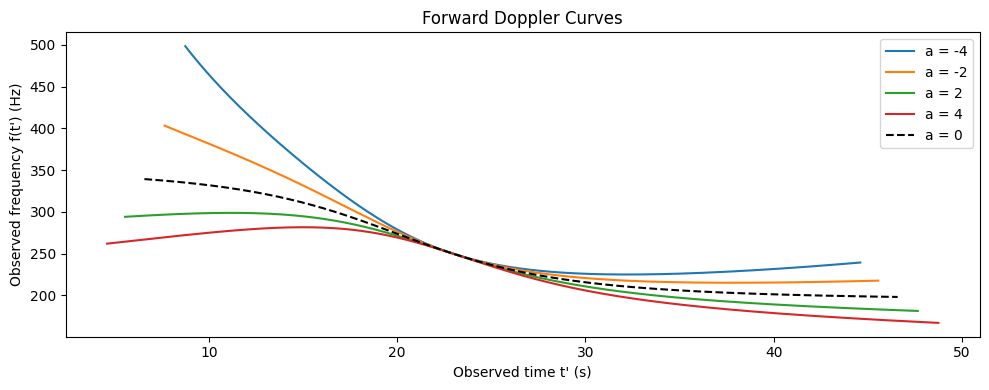

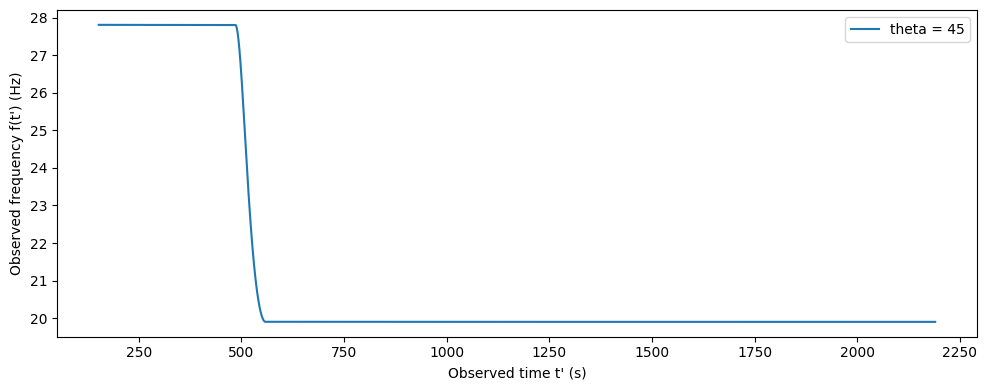

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== 核心通用工具 =====================

def arrival_time(t_emit, pos, c=340.0):
    """t' = t + R/c  （文中式(2)）"""
    R = np.linalg.norm(pos, axis=1)
    return t_emit + R / c  #  [oai_citation:5‡YPan_Air_Traffic_Events.pdf](file-service://file-5KcjWetqeLxwhVqQvekEEt)

def radial_velocity(pos, vel):
    """v_r = d|pos|/dt = (pos · vel)/|pos|"""
    R = np.linalg.norm(pos, axis=1)
    # 避免除零
    R = np.where(R == 0, 1e-12, R)
    vr = np.einsum('ij,ij->i', pos, vel) / R
    return vr

def observed_frequency(f0, vr, c=340.0):
    """f(t') = f0 / (1 + vr/c)  （文中式(5)）"""
    return f0 / (1.0 + vr / c)  #  [oai_citation:6‡YPan_Air_Traffic_Events.pdf](file-service://file-5KcjWetqeLxwhVqQvekEEt)

def sort_by_tprime(t_prime, arrs):
    """将所有数组按 t' 升序重排（保证正演输出的时间是观测时刻）"""
    idx = np.argsort(t_prime)
    tps = t_prime[idx]
    outs = [a[idx] for a in arrs]
    return tps, outs

# ===================== 1) 直线加/减速正演 =====================

def forward_accel(
    f0=25.0, l=1000.0, v0=100.0, a=-3.0, t0=20.0,
    t_min=0.0, t_max=40.0, dt=0.01, c=340.0
):
    """
    直线加/减速：轨迹为 (x(t), y=l)，x(t) = v0*(t-t0) + 0.5*a*(t-t0)^2
    v(t) = v0 + a*(t-t0)
    """
    t = np.arange(t_min, t_max + dt, dt)
    tau = t - t0
    x = v0 * tau + 0.5 * a * tau**2
    y = np.full_like(x, l)

    # 速度向量
    vx = v0 + a * tau
    vy = np.zeros_like(vx)

    pos = np.stack([x, y], axis=1)
    vel = np.stack([vx, vy], axis=1)

    # 频率与到时（文中式(5)与式(2)）
    vr = radial_velocity(pos, vel)
    f_obs = observed_frequency(f0, vr, c)   #  [oai_citation:7‡YPan_Air_Traffic_Events.pdf](file-service://file-5KcjWetqeLxwhVqQvekEEt)
    t_prime = arrival_time(t, pos, c)       #  [oai_citation:8‡YPan_Air_Traffic_Events.pdf](file-service://file-5KcjWetqeLxwhVqQvekEEt)

    # 输出按观测时刻 t' 排序
    t_prime, (f_obs, x, y) = sort_by_tprime(t_prime, [f_obs, x, y])
    return t_prime, f_obs, x, y

# ===================== 2) 转弯（两直线+圆弧）正演 =====================

def _solve_tangent_x_for_turn(l1, l2, r, theta, ccw=True):
    """
    已知：第一段直线 y=l1（方向沿 +x），第二段直线方向角 theta（弧度），
    要求：找到第一段与圆弧的切点 x1（即 P1.x），使得圆弧结束点 P2 处切线方向为 theta，
    且“通过 P2 的第二段直线”的到原点的有符号垂距为 l2。

    几何设定：
      - 如果 ccw=True（左转，theta>0），圆心在 y = l1 + r；否则 y = l1 - r。
      - 初始切点 P1 = (x1, l1)；对应圆心 C = (x1, l1 + s*r)，s = +1 (ccw) 或 -1 (cw)
      - 初始径向角 alpha0 = -pi/2 (ccw) 或 +pi/2 (cw)
      - 终止径向角 alpha = alpha0 + theta
      - P2 = C + r * [cos alpha, sin alpha]
      - 第二段直线法向量 n2 = (-sin theta, cos theta)
      - 约束：有符号距离 d = n2 · P2 = l2
    """
    s = +1 if ccw else -1
    alpha0 = -np.pi/2 if ccw else +np.pi/2
    n2 = np.array([-np.sin(theta), np.cos(theta)])

    def signed_distance_from_x1(x1):
        C = np.array([x1, l1 + s * r])
        alpha = alpha0 + theta
        P2 = C + r * np.array([np.cos(alpha), np.sin(alpha)])
        d = float(n2 @ P2)
        return d - l2  # root target

    # 用简单的二分法在较大的区间内搜索根
    lo, hi = -20000.0, 20000.0
    flo, fhi = signed_distance_from_x1(lo), signed_distance_from_x1(hi)
    if flo * fhi > 0:
        # 若同号，扩大区间再试一次
        lo, hi = lo * 10, hi * 10
        flo, fhi = signed_distance_from_x1(lo), signed_distance_from_x1(hi)
        if flo * fhi > 0:
            raise RuntimeError("无法为当前参数找到圆弧切点（请检查 l1,l2,r,theta 是否可几何连通）")

    for _ in range(100):
        mid = 0.5 * (lo + hi)
        fmid = signed_distance_from_x1(mid)
        if abs(fmid) < 1e-6:
            return mid
        if flo * fmid <= 0:
            hi, fhi = mid, fmid
        else:
            lo, flo = mid, fmid
    return 0.5 * (lo + hi)

def forward_turn(
    f0=25.0, l1=600.0, l2=-20.0, v0=100.0, r=100.0, theta_deg=173.0, t0=20.0,
    t_pre=10.0, t_arc=None, t_post=10.0, dt=0.02, c=340.0
):
    """
    转弯：直线1 (y=l1, 朝 +x)  ->  半径 r 的圆弧（转角 theta） ->  直线2（方向角 theta，垂距 l2）
    - 默认为左转（theta>0）；若给出 theta_deg<0，则右转。
    - t_pre / t_post 控制转弯前后直线段的持续时间（匀速 v0）
    - t_arc 若为 None，自动设为 弧长/v0 = (r*|theta|)/v0
    """
    theta = np.deg2rad(theta_deg)
    ccw = theta > 0  # 左转/右转
    x1 = _solve_tangent_x_for_turn(l1, l2, r, theta, ccw=ccw)
    s = +1 if ccw else -1
    alpha0 = -np.pi/2 if ccw else +np.pi/2
    C = np.array([x1, l1 + s * r])

    # --- 段1：转弯前直线（朝 +x）
    n1 = int(np.ceil(t_pre / dt))
    t1 = np.arange(n1) * dt
    P1 = np.column_stack([x1 - v0 * (t_pre - t1), np.full(n1, l1)])
    V1 = np.column_stack([np.full(n1, v0), np.zeros(n1)])

    # --- 段2：圆弧
    if t_arc is None:
        t_arc = abs(r * theta) / v0
    n2 = max(2, int(np.ceil(t_arc / dt)))
    t2 = np.linspace(0.0, t_arc, n2)
    alpha = alpha0 + (theta) * (t2 / t_arc)  # 均匀沿弧长
    P2 = np.column_stack([C[0] + r * np.cos(alpha), C[1] + r * np.sin(alpha)])
    # 圆弧切向速度方向：沿 CCW 为 [-sin, cos]；沿 CW 为 [sin, -cos]
    tang = np.column_stack([-np.sin(alpha), np.cos(alpha)]) if ccw else np.column_stack([np.sin(alpha), -np.cos(alpha)])
    V2 = v0 * tang

    # --- 段3：转弯后直线（方向角 theta）
    d2 = np.array([np.cos(theta), np.sin(theta)])
    n3 = int(np.ceil(t_post / dt))
    t3 = np.arange(n3) * dt
    P3 = P2[-1] + np.outer(t3, v0 * d2)
    V3 = np.tile(v0 * d2, (n3, 1))

    # 串接
    pos = np.vstack([P1, P2, P3])
    vel = np.vstack([V1, V2, V3])

    # 时间轴（发射时刻）带上 t0 偏移
    t_emit = np.concatenate([t1, t_pre + t2, t_pre + t_arc + t3]) + (t0 - t_pre)

    # 正演：f(t'), t'
    vr = radial_velocity(pos, vel)
    f_obs = observed_frequency(f0, vr, c)     #  [oai_citation:9‡YPan_Air_Traffic_Events.pdf](file-service://file-5KcjWetqeLxwhVqQvekEEt)
    t_prime = arrival_time(t_emit, pos, c)    #  [oai_citation:10‡YPan_Air_Traffic_Events.pdf](file-service://file-5KcjWetqeLxwhVqQvekEEt)

    # 输出按 t' 排序
    t_prime, (f_obs, pos) = sort_by_tprime(t_prime, [f_obs, pos])
    return t_prime, f_obs, pos[:,0], pos[:,1]

# ===================== 示例与绘图 =====================

if __name__ == "__main__":
    # 示例1：加速/减速（参数参考图3(d)示意
    tprime1, f1, x1, y1 = forward_accel(f0=250, l=1000, v0=100, a=-4.0, 
                                        t0=20, t_min=0, t_max=40, dt=0.001)
    tprime2, f2, x2, y2 = forward_accel(f0=250, l=1000, v0=100, a=-2.0, 
                                        t0=20, t_min=0, t_max=40, dt=0.001)
    tprime3, f3, x3, y3 = forward_accel(f0=250, l=1000, v0=100, a=2.0, 
                                        t0=20, t_min=0, t_max=40, dt=0.001)
    tprime4, f4, x4, y4 = forward_accel(f0=250, l=1000, v0=100, a=4.0, 
                                        t0=20, t_min=0, t_max=40, dt=0.001)
    tprime, f, x, y = forward_accel(f0=250, l=1000, v0=100, a=0.0, 
                                        t0=20, t_min=0, t_max=40, dt=0.001)

    # 画频率-观测时刻曲线
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(tprime1, f1, label="a = -4")
    ax.plot(tprime2, f2, label="a = -2")
    ax.plot(tprime3, f3, label="a = 2")
    ax.plot(tprime4, f4, label="a = 4")
    ax.plot(tprime, f, 'k--', label="a = 0")
    ax.set_xlabel("Observed time t' (s)")
    ax.set_ylabel("Observed frequency f(t') (Hz)")
    ax.set_title("Forward Doppler Curves")
    ax.legend()
    fig.tight_layout()
    fig.savefig("forward_doppler_curves_accel.png")
    plt.show()

    # 示例2：转弯（靠近台站的大角度转弯，近似对应图4(a)风格；图3(b)给出了参数刻画方式）
    # 这里取 l1=600 m, l2=-20 m, r=100 m, theta=173°，与文中示例量级一致  
    tprime1, f1, x1, y1 = forward_turn(f0=23.2, l1=1658.5, l2=1320.3, v0=56.4, 
                                        r=1360.2, theta_deg=169.9, 
                                        t0=391.5, t_pre=400, t_post=1400, dt=0.02)
    tprime2, f2, x2, y2 = forward_turn(f0=250, l1=600, l2=-20, v0=100, 
                                        r=100, theta_deg=90, 
                                        t0=20, t_pre=10, t_post=10, dt=0.02)
    tprime3, f3, x3, y3 = forward_turn(f0=250, l1=600, l2=-20, v0=100, 
                                        r=100, theta_deg=135, 
                                        t0=20, t_pre=10, t_post=10, dt=0.02)

    fig1, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(tprime1, f1, label="theta = 45")
    # ax1.plot(tprime2, f2, label="theta = 90")
    # ax1.plot(tprime3, f3, label="theta = 135")
    # ax1.set_title("f0=250Hz, l1=600m, l2=-20m, r=100m, t0=20s, t_pre=10s, t_post=10s", fontsize=12)
    ax1.set_xlabel("Observed time t' (s)")
    ax1.set_ylabel("Observed frequency f(t') (Hz)")

    ax1.legend()
    fig1.tight_layout()
    fig1.savefig("forward_doppler_curves_turn.png")
    plt.show()


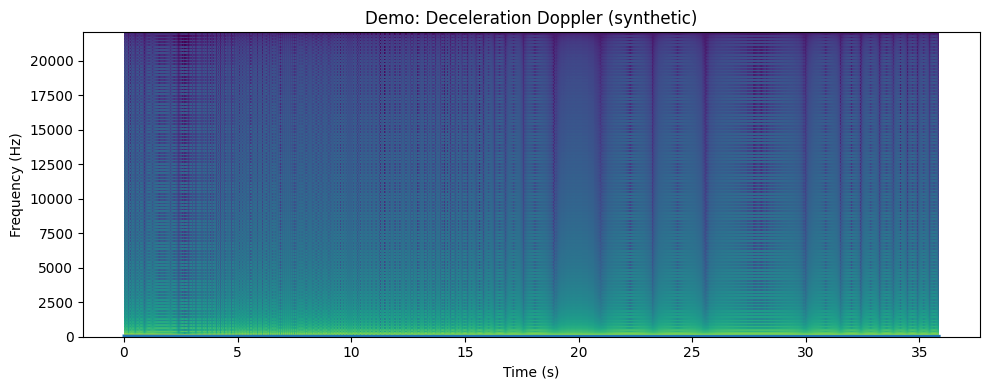

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from typing import Tuple

def compute_stft(signal: np.ndarray, fs: float,
                 nperseg: int = 1024, noverlap: int = 1000, nfft: int = 2048):
    """
    Compute STFT magnitude (log-scaled) similar to the paper's settings:
    - window length: 1024 samples
    - overlap: 1000 samples
    - FFT length: 2048
    Returns (T, F, Sxx_db), where T: seconds, F: Hz.
    """
    f, t, Zxx = stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, boundary=None)
    S = np.abs(Zxx)
    S_db = 20 * np.log10(np.maximum(S, 1e-12))
    return t, f, S_db

def overlay_curve_on_spectrogram(t_spec: np.ndarray, f_spec: np.ndarray, S_db: np.ndarray,
                                 tprime_curve: np.ndarray, f_curve: np.ndarray,
                                 vmin=None, vmax=None, title="Spectrogram with Doppler Curve"):
    """
    Plot STFT spectrogram and overlay (t', f(t')) curve.
    """
    plt.figure(figsize=(10, 4))
    plt.pcolormesh(t_spec, f_spec, S_db, shading='auto')
    plt.plot(tprime_curve, f_curve, linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    if title:
        plt.title(title)
    if vmin is not None or vmax is not None:
        plt.clim(vmin=vmin, vmax=vmax)
    plt.tight_layout()
    plt.show()

# -------- Optional demo (synthetic): make an AM signal that roughly follows f(t') --------
def synth_from_curve(tprime: np.ndarray, f_curve: np.ndarray, fs: float, duration: float) -> np.ndarray:
    """
    Very simple synthesis: generate a sinusoid whose instantaneous frequency follows a time-frequency curve.
    We resample f_curve onto uniform time grid [0, duration]. This is not a physical propagation model,
    but sufficient to visualize an overlay demo.
    """
    t = np.linspace(0.0, duration, int(duration * fs), endpoint=False)
    f_interp = np.interp(t, np.clip(tprime, tprime.min(), tprime.max()), f_curve)
    phase = 2 * np.pi * np.cumsum(f_interp) / fs
    sig = 0.5 * np.sin(phase)
    sig += 0.2 * np.sin(2 * phase)
    return sig

if __name__ == "__main__":
    # Example if run directly (requires forward_models.py to be importable)
    from forward_models import forward_accel
    tprime, f_obs, x1, y1 = forward_accel(f0=25, l=1000, v0=100, a=-4.0, t0=20, t_min=0, t_max=40, dt=0.02)
    fs = 44100.0
    duration = float(tprime.max() - tprime.min())
    sig = synth_from_curve(tprime - tprime.min(), f_obs, fs=fs, duration=duration)
    t_spec, f_spec, S_db = compute_stft(sig, fs=fs)
    overlay_curve_on_spectrogram(t_spec, f_spec, S_db, tprime - tprime.min(), f_obs,
                                 title="Demo: Deceleration Doppler (synthetic)")


In [ ]:
{
    'sps'          : 1000.0,
    'samp_freq'    : 1000.0,
    'ishot_inf'    : 24,
    'freqmin'      : 2.0,
    'freqmax'      : 30.0,
    'freq_norm'    : 'rma',
    'time_norm'    : 'no',
    'cc_method'    : 'coherency',
    'smooth_N'     : 5,
    'smoothspect_N': 5,
    'maxlag'       : 0.4,
    'max_over_std' : 1000000000,
    'cc_len'       : 1.0,
    'cha1'         : 0.0,
    'cha2'         : 1000.0,
    'cc_path'      : '/Users/zhangzhiyu/Desktop/output'
}

In [ ]:
{
    'sps'          : 1000.0,
    'samp_freq'    : 1000.0,
    'ishot_inf'    : 24,
    'freqmin'      : 2.0,
    'freqmax'      : 30.0,
    'freq_norm'    : 'rma',
    'time_norm'    : 'no',
    'cc_method'    : 'coherency',
    'smooth_N'     : 5,
    'smoothspect_N': 5,
    'maxlag'       : 0.4,
    'max_over_std' : 1000000000,
    'cc_len'       : 1.0,
    'cha1'         : 0.0,
    'cha2'         : 1000.0,
    'cc_path'      : '/Users/zhangzhiyu/Desktop/output'
}